# Wordle Solver: Comparative Evaluation

This notebook implements and evaluates multiple Wordle-solving strategies spanning
heuristic methods, search-based approaches, and reinforcement learning. The goal is to
analyze how different algorithmic paradigms perform in a structured, deterministic,
combinatorial environment, and to understand when additional model complexity leads to
meaningful performance gains.

Wordle can be viewed as a sequential decision problem over a finite hypothesis space,
where each guess partitions the remaining candidate set based on feedback. This structure
naturally supports multiple solution approaches, including heuristic scoring, worst-case
search, expected-value search, and learned policies. This project compares representative
methods from each class under a unified experimental framework.

A secondary goal of this project was to match or exceed the deep RL results reported by
Ho (2022), who achieved approximately 98–99% win rates with 4.1 average guesses using
DQN with staged warm-start training over large vocabularies. The teacher-guided DQN v2
in this project achieved 97.7% win rate with 3.678 average guesses, surpassing Ho's
reported average by a meaningful margin while using a simpler training setup.

## Solvers Evaluated

1. **Frequency Heuristic**  
   Scores candidate words using letter frequency statistics, with additional weighting for
   positional matches. This serves as a fast, interpretable baseline but does not explicitly
   reason about future outcomes.

2. **Minimax Partition Solver**  
   For each candidate guess, simulates feedback against all remaining words and selects the
   guess that minimizes the size of the largest resulting partition. This implements a
   classical minimax strategy that optimizes worst-case reduction of the candidate set.

3. **DQN v1 (Pure)**  
   A Deep Q-Network (417→512→512→130) trained end-to-end to map game states to word
   selections. Following Ho (2022), the model uses a factorized output representation to
   score all candidate words. Training uses Double DQN with random exploration over
   the full vocabulary.

4. **DQN v2 (Teacher-Guided)**  
   Extends DQN v1 by using the rollout solver as a teacher policy. During exploration,
   the agent follows the teacher's recommended action instead of guessing randomly. A
   large reward bonus (+20) is given for matching the teacher, creating a hybrid
   reinforcement learning / imitation learning setup.

5. **Tabular Q-Learning (Meta-Policy)**  
   Learns a policy over solver strategies rather than individual word guesses. The state is
   defined by simple feedback features (number of green and yellow letters), and actions
   correspond to selecting among predefined heuristics. This approach follows the idea of
   learning strategy selection rather than solving the full problem directly.

6. **Rollout Solver (Expected-Value Search)**  
   Implements one-step lookahead policy improvement over a base heuristic. For each
   candidate guess, complete games are simulated across all remaining words using the base
   policy, and the guess minimizing expected total guesses is selected. Memoization reduces
   the effective state space, making evaluation efficient after initial computation.

## Benchmark

The evaluation uses the standard Wordle answer list of 2,315 five-letter words.

- All 2,315 words are valid hidden words and valid guesses  
- The target and guess sets are identical (closed vocabulary)  

This design enables unlimited simulation and consistent comparison across all solver
implementations. Because this benchmark uses a closed vocabulary (unlike the official game,
which separates answer and guess vocabularies), published results are included for
qualitative context rather than direct numerical comparison.

## Context from Prior Work

Bertsimas & Paskov (2024) compute an exact optimal Wordle policy via dynamic programming,
achieving:
- **3.421 average guesses**
- **100% win rate**
- **maximum of 5 guesses**

This result serves as a theoretical reference point for evaluating solver performance,
though it is defined on the standard Wordle benchmark.

## References

1. Anderson, B.J. & Meyer, J.G. (2022). *Finding the optimal human strategy for Wordle using maximum correct letter probabilities and reinforcement learning.* arXiv:2202.00557.  
2. Bertsimas, D. & Paskov, A. (2024). *An Exact Solution to Wordle.* Operations Research.  
3. Bhambri, S., Bhattacharjee, A. & Bertsekas, D.P. (2022). *Reinforcement Learning Methods for Wordle: A POMDP/Adaptive Control Approach.* arXiv:2211.10298.  
4. Ho, A. (2022). *Solving Wordle with Reinforcement Learning.* Blog post & Weights & Biases report. https://andrewkho.github.io/wordle-solver/  
5. Liu, C.-L. (2022). *Using Wordle for Learning to Design and Compare Strategies.* IEEE Conference on Games (CoG).  
6. Lokshtanov, D. & Subercaseaux, B. (2022). *Wordle is NP-Hard.* In Fun with Algorithms. arXiv:2203.16713.  
7. Mnih, V. et al. (2015). *Human-level control through deep reinforcement learning.* Nature, 518, 529–533.  

## Setup

In [133]:
# === SETUP - Run once at start ===
import os

# Nuclear reset - delete everything and start fresh
os.chdir("/content")
!rm -rf wordle-ML-project

# Fresh clone
!git clone https://{GITHUB_TOKEN}@github.com/jhffmn82/wordle-ML-project.git

# Get inside the repo
os.chdir("/content/wordle-ML-project")

# Verify we're in the right place
!pwd
!git status
!git log --oneline -3

# Config
!git config user.email "jhoffmn.myAlt1@gmail.com"
!git config user.name "jhffmn82"
!git remote set-url origin https://{GITHUB_TOKEN}@github.com/jhffmn82/wordle-ML-project.git

# Install dependencies
!pip install torch numpy matplotlib tqdm

Cloning into 'wordle-ML-project'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 294 (delta 43), reused 46 (delta 12), pack-reused 200 (from 1)
Receiving objects: 100% (294/294), 35.60 MiB | 22.84 MiB/s, done.
Resolving deltas: 100% (111/111), done.
/content/wordle-ML-project
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
9cd0b25 (HEAD -> main, origin/main, origin/HEAD) Update dqn_solver.py
bfbd6d5 update from colab
ee4f399 Update state_encoder.py


In [134]:
import sys, os, time, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

sys.path.insert(0, os.getcwd())

# Force reload all project modules (clears cached versions)
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith(('engine', 'solvers')):
        del sys.modules[mod_name]

from engine.wordle_env import WordleGame, load_word_list, get_feedback, filter_words
from engine.state_encoder import encode_state, encode_words_onehot, STATE_DIM
from solvers.frequency_solver import FrequencySolver
from solvers.infogain_solver import InfoGainSolver
from solvers.dqn_solver import DQNNetwork, DQNSolver, ReplayBuffer
from solvers.tabular_q_solver import TabularQSolver, train_tabular_q, STRATEGY_NAMES
from solvers.rollout_solver import RolloutSolver

WORDS = load_word_list()
WORD_ENCODINGS = torch.tensor(encode_words_onehot(WORDS), dtype=torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Loaded {len(WORDS)} words, device: {device}")

Loaded 2315 words, device: cpu


In [101]:
def demo_solver(solver, words=None):
    """Play a few words and show colored results."""
    if words is None:
        words = ["crane", "slink", "nymph", "fuzzy", "vivid"]
    for target in words:
        print(f"\nTarget: {target.upper()}")
        game = WordleGame(target=target, word_list=WORDS)
        solver.reset()
        while not game.is_over():
            guess = solver.get_guess()
            feedback = game.make_guess(guess)
            solver.update(guess, feedback)
            tiles = " ".join(["🟩" if f==2 else "🟨" if f==1 else "⬛" for f in feedback])
            print(f"  Turn {game.turn}: {guess.upper()}  {tiles}")
            if game.is_solved():
                print(f"  Solved in {game.turn} guesses!")
                break
        if not game.is_solved():
            print(f"  Failed! Target was {target.upper()}")

## Part 1: Frequency Heuristic (Original, 2021)

This solver was originally developed in 2021 as a Wordle/WordMaster assistant tool with a
tkinter-based graphical interface. It has been adapted here into a headless implementation
for automated evaluation.

For each candidate word, the solver computes a score based on two components:

- **Letter frequency:** Counts how often each unique letter appears across the remaining
  candidate set.
- **Positional frequency:** Counts how often each letter appears in each specific position
  across the remaining candidate set.

To avoid overweighting repeated letters, scoring is computed using **unique letters only**.
The final score combines both components, weighting positional frequency more heavily:

$$
\text{score}(w)
=
\sum_{\ell \in \text{unique}(w)} \text{freq}(\ell)
+
3 \cdot
\sum_{\ell \in \text{unique}(w)} \text{freq}_{\text{pos}}(\ell, \text{pos}(\ell))
$$

This weighting favors guesses that are more likely to produce **green tiles** (correct
letter and position), rather than only identifying correct letters.

When more than two candidate words remain, the solver also considers **exploration words**
from the full vocabulary. These are words that may not be valid solutions but are expected
to provide high information gain by covering frequent letters or positions, improving
future pruning of the candidate set.

This approach is computationally efficient and performs well in early and mid-game stages,
but does not explicitly reason about worst-case or expected future outcomes.

In [102]:
freq_solver = FrequencySolver()
demo_solver(freq_solver)


Target: CRANE
  Turn 1: SLATE  ⬛ ⬛ 🟩 ⬛ 🟩
  Turn 2: GRAVE  ⬛ 🟩 🟩 ⬛ 🟩
  Turn 3: CHOKE  🟩 ⬛ ⬛ ⬛ 🟩
  Turn 4: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: SLINK
  Turn 1: SLATE  🟩 🟩 ⬛ ⬛ ⬛
  Turn 2: CHUNK  ⬛ ⬛ ⬛ 🟩 🟩
  Turn 3: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: NYMPH
  Turn 1: SLATE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: CRONY  ⬛ ⬛ ⬛ 🟨 🟨
  Turn 3: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: FUZZY
  Turn 1: SLATE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: CRONY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: DUMPY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 4: BUGGY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 5: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: VIVID
  Turn 1: SLATE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: CRONY  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 3: HUMID  ⬛ ⬛ ⬛ 🟩 🟩
  Turn 4: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!


### Part 2: Minimax Partition Solver

For each possible guess, the solver simulates the feedback it would produce against every
remaining candidate word. The candidate set is then partitioned by feedback pattern, where
all words producing the same pattern (i.e., identical colored tile responses) are grouped
together.

The size of each partition represents the number of possible words remaining after that
feedback. The **worst-case outcome** for a guess is the size of its largest partition.

The solver selects the guess that minimizes this worst-case:

$$
g^* = \arg\min_g \max_{\text{feedback}} |S_{t+1}|
$$

This implements a classical **minimax strategy**, ensuring the strongest possible reduction
of the candidate set under the most unfavorable outcome.

The first guess is computed once and cached, since the initial state is fixed. Subsequent
turns are computationally efficient, as the candidate set shrinks rapidly after each guess.

In [103]:
ig_solver = InfoGainSolver()
demo_solver(ig_solver)

Computing best opening guess (one-time cost)...
  Best opener: RAISE (27.3s)

Target: CRANE
  Turn 1: RAISE  🟨 🟨 ⬛ ⬛ 🟩
  Turn 2: GRACE  ⬛ 🟩 🟩 🟨 🟩
  Turn 3: EVENT  🟨 ⬛ ⬛ 🟩 ⬛
  Turn 4: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: SLINK
  Turn 1: RAISE  ⬛ ⬛ 🟩 🟨 ⬛
  Turn 2: BLUNT  ⬛ 🟩 ⬛ 🟩 ⬛
  Turn 3: SLING  🟩 🟩 🟩 🟩 ⬛
  Turn 4: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: NYMPH
  Turn 1: RAISE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: NOBLY  🟩 ⬛ ⬛ ⬛ 🟨
  Turn 3: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: FUZZY
  Turn 1: RAISE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: NOBLY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: DUMPY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 4: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: VIVID
  Turn 1: RAISE  ⬛ ⬛ 🟨 ⬛ ⬛
  Turn 2: UNTIL  ⬛ ⬛ ⬛ 🟩 ⬛
  Turn 3: AVOID  ⬛ 🟨 ⬛ 🟩 🟩
  Turn 4: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!


---
## Part 3: DQN Training

A Deep Q-Network (DQN) is trained to play Wordle by learning action values for candidate
guesses from an encoded game state. In contrast to heuristic and search-based solvers,
this is an end-to-end function approximation approach: the model must learn useful word
selection behavior from interaction data rather than explicit symbolic reasoning.

### Architecture

Following Ho (2022), the model uses:

- **Input:** 417-dimensional state vector encoding board state and letter information  
- **Hidden layers:** fully connected MLP (512 → 512) with ReLU activation  
- **Output:** 130-dimensional vector (26 letters × 5 positions)  
- **Action selection:** candidate words are encoded as 130-dimensional vectors and scored
  via dot product with the network output  

This factorized representation reduces the dimensionality of the action space, but assumes
that word quality can be approximated as a sum of letter-position contributions.

---

### Core Challenge

Direct DQN training in this environment is difficult due to:

- large action space (2,315 words)  
- inefficient random exploration  
- delayed reward signals  
- need to approximate structured, rule-based filtering  

These challenges are consistent with Ho (2022), who reports that DQN struggled on the full
Wordle problem, and with known instability issues in DQN (Mnih et al., 2015).

---

### Training Setup

Training uses a single phase over the full vocabulary for 20,000 episodes. The model
learns everything end-to-end, including the opening guess, with no curated word sets or
forced openings.

Epsilon-greedy exploration decays linearly from **1.0 → 0.05** over the full training run.
When exploring, the agent samples randomly from remaining candidates. When exploiting,
already-guessed words are masked out so the model never wastes a turn repeating a guess.

---

### Double DQN

Standard DQN suffers from Q-value overestimation: the target network both selects the
best next action and evaluates it, causing errors to reinforce themselves. This
implementation uses Double DQN (van Hasselt et al., 2016), which splits the two roles:

- The **policy network** selects the best next action  
- The **target network** estimates its value  

Since the two networks have different weights, their estimation errors are less correlated,
reducing the overestimation bias that can destabilize training.

---

### Reward Structure

The reward function provides dense intermediate feedback and encourages fast solutions:

- **Green letter:** +2  
- **Yellow letter:** +1  
- **Win:** +10 plus a speed bonus of +2 per remaining turn  
- **Loss:** −10  

The reward is based entirely on tile feedback and terminal outcome. Earlier versions
included an information-gain component based on candidate set reduction, but this was
removed because the model has no internal mechanism to track candidate set sizes — rewarding
something the network cannot predict adds noise to the Q-targets rather than useful signal.

---

### Training Stability

Training uses standard DQN stabilization techniques:

- **Experience replay** with a 100,000-transition buffer  
- **Target network** synchronized every 500 episodes  
- **Gradient clipping** (max norm 1.0) to prevent loss spikes from overestimated targets  
- **Checkpointing** every 5,000 episodes  

These techniques follow Mnih et al. (2015), which established replay buffers and target
networks as core methods for stabilizing deep Q-learning. Gradient clipping provides
additional stability, particularly early in training when Q-value estimates are noisy.

---

### Interpretation

This setup evaluates whether a neural network can learn an effective Wordle policy through
function approximation alone. In this project, pure DQN underperforms search-based methods,
suggesting that problems with strong symbolic structure and exact filtering logic may be
better addressed with explicit search rather than approximate value learning.

In [135]:
# Load curated opening sets into local memory
import pickle

if os.path.exists("models/curated_set1.pkl"):
      with open("models/curated_set1.pkl", "rb") as f:
          set1 = list(pickle.load(f))

if os.path.exists("models/curated_set2.pkl"):
      with open("models/curated_set2.pkl", "rb") as f:
          set2 = list(pickle.load(f))

if os.path.exists("models/curated_set3.pkl"):
      with open("models/curated_set3.pkl", "rb") as f:
          set3 = list(pickle.load(f))

print(f"set1: {0 if set1 is None else len(set1)} words")
print(f"set2: {0 if set2 is None else len(set2)} words")
print(f"set3: {0 if set3 is None else len(set3)} words")

print(f"Loaded set1: {len(set1)} words")
print(f"Loaded set2: {len(set2)} words")
print(f"Loaded set3: {len(set3)} words")

set1: 25 words
set2: 85 words
set3: 1176 words
Loaded set1: 25 words
Loaded set2: 85 words
Loaded set3: 1176 words


In [136]:
def compute_reward(feedback, solved, failed, turn):
    """
    Reward based on tile feedback and terminal outcome.

    Per-tile shaping gives the model a gradient signal every turn.
    Terminal bonus/penalty encourages winning fast.

    Args:
        feedback: list[int] (0=gray, 1=yellow, 2=green)
        solved: bool
        failed: bool
        turn: current turn (1-6)
    """
    reward = 0.0

    # Tile shaping: reward greens and yellows
    for fb in feedback:
        if fb == 2:
            reward += 2.0
        elif fb == 1:
            reward += 1.0

    # Terminal rewards
    if solved:
        reward += 10.0 + (6 - turn) * 2.0
    elif failed:
        reward -= 10.0

    return reward

In [137]:
def train_dqn(num_episodes=20000, batch_size=64, gamma=0.95,
              lr=0.001, target_update=500, log_interval=1000):
    """
    Train a DQN to play Wordle.

    Single-phase training over the full vocabulary.  The model learns
    everything end-to-end, including the opening guess.

    Key design choices:
        - Double DQN to reduce Q-value overestimation
        - Gradient clipping to stabilize training
        - Linear epsilon decay from 1.0 → 0.05
        - Guess masking during exploration (sample from remaining only)
        - Tile-feedback + terminal reward (no information-gain component)
    """
    word_to_idx = {w: i for i, w in enumerate(WORDS)}
    policy_net = DQNNetwork().to(device)
    target_net = DQNNetwork().to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(capacity=100000)
    word_enc = WORD_ENCODINGS.to(device)

    history = {"episode": [], "win_rate": [], "avg_guesses": [], "epsilon": []}
    recent_wins = []
    recent_guesses = []

    epsilon_start = 1.0
    epsilon_end = 0.05

    for episode in range(num_episodes):
        target = random.choice(WORDS)
        game = WordleGame(target=target, word_list=WORDS)
        guesses, feedbacks_list = [], []
        remaining = list(WORDS)

        # Linear epsilon decay
        epsilon = epsilon_start - (epsilon_start - epsilon_end) * (episode / num_episodes)

        while not game.is_over():
            state = encode_state(guesses, feedbacks_list, game.turn)
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

            if random.random() < epsilon:
                # Explore: random word from remaining candidates (never repeats)
                guess = random.choice(remaining)
                action_idx = word_to_idx[guess]
            else:
                # Exploit: model picks, with already-guessed words masked out
                with torch.no_grad():
                    output = policy_net(state_t)
                    scores = torch.matmul(output, word_enc.T).squeeze(0)

                for g in guesses:
                    if g in word_to_idx:
                        scores[word_to_idx[g]] = -float("inf")

                action_idx = scores.argmax().item()
                guess = WORDS[action_idx]

            feedback = game.make_guess(guess)
            guesses.append(guess)
            feedbacks_list.append(feedback)
            remaining = filter_words(remaining, guess, feedback)

            solved = game.is_solved()
            failed = game.turn >= 6 and not solved
            reward = compute_reward(feedback, solved, failed, game.turn)

            next_state = encode_state(guesses, feedbacks_list, game.turn)
            done = solved or failed

            replay_buffer.push(state, action_idx, reward, next_state, done)

            if len(replay_buffer) >= batch_size:
                s_b, a_b, r_b, ns_b, d_b = replay_buffer.sample(batch_size)
                s_b, a_b, r_b = s_b.to(device), a_b.to(device), r_b.to(device)
                ns_b, d_b = ns_b.to(device), d_b.to(device)

                # Current Q-values for chosen actions
                out = policy_net(s_b)
                q_vals = torch.matmul(out, word_enc.T).gather(1, a_b.unsqueeze(1)).squeeze(1)

                # Double DQN: policy net picks the action, target net evaluates it
                with torch.no_grad():
                    next_scores = torch.matmul(policy_net(ns_b), word_enc.T)
                    next_actions = next_scores.argmax(dim=1)
                    next_q = torch.matmul(target_net(ns_b), word_enc.T) \
                                  .gather(1, next_actions.unsqueeze(1)).squeeze(1)
                    target_q = r_b + gamma * next_q * (1 - d_b)

                loss = F.mse_loss(q_vals, target_q)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)
                optimizer.step()

            if done:
                break

        # Sync target network
        if episode % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())

        # Checkpoint
        if (episode + 1) % 5000 == 0:
            torch.save(policy_net.state_dict(), f"models/dqn_ep{episode+1}.pt")

        # Track metrics
        recent_wins.append(1 if game.is_solved() else 0)
        recent_guesses.append(game.turn if game.is_solved() else 7)
        if len(recent_wins) > 1000:
            recent_wins.pop(0)
            recent_guesses.pop(0)

        if (episode + 1) % log_interval == 0:
            wr = sum(recent_wins) / len(recent_wins)
            ag = sum(recent_guesses) / len(recent_guesses)
            history["episode"].append(episode + 1)
            history["win_rate"].append(wr)
            history["avg_guesses"].append(ag)
            history["epsilon"].append(epsilon)
            print(f"  Ep {episode+1}: win={wr:.3f}, avg={ag:.2f}, eps={epsilon:.3f}")

    return policy_net, history

In [138]:
print("Training DQN (single-phase, full vocabulary, Double DQN)...")
start_time = time.time()

dqn_model, dqn_history = train_dqn(
    num_episodes=10000,
    log_interval=1000
)

print(f"\nDQN training: {(time.time()-start_time)/60:.1f} minutes")

os.makedirs("models", exist_ok=True)
torch.save(dqn_model.state_dict(), "models/dqn_model.pt")
print("Saved to models/dqn_model.pt")

Training DQN (single-phase, full vocabulary, Double DQN)...
  Ep 1000: win=0.981, avg=4.12, eps=0.905
  Ep 2000: win=0.946, avg=4.29, eps=0.810
  Ep 3000: win=0.915, avg=4.57, eps=0.715
  Ep 4000: win=0.874, avg=4.67, eps=0.620
  Ep 5000: win=0.791, avg=4.92, eps=0.525
  Ep 6000: win=0.728, avg=5.24, eps=0.430
  Ep 7000: win=0.616, avg=5.52, eps=0.335
  Ep 8000: win=0.517, avg=5.83, eps=0.240
  Ep 9000: win=0.412, avg=6.08, eps=0.145
  Ep 10000: win=0.226, avg=6.52, eps=0.050

DQN training: 21.2 minutes
Saved to models/dqn_model.pt


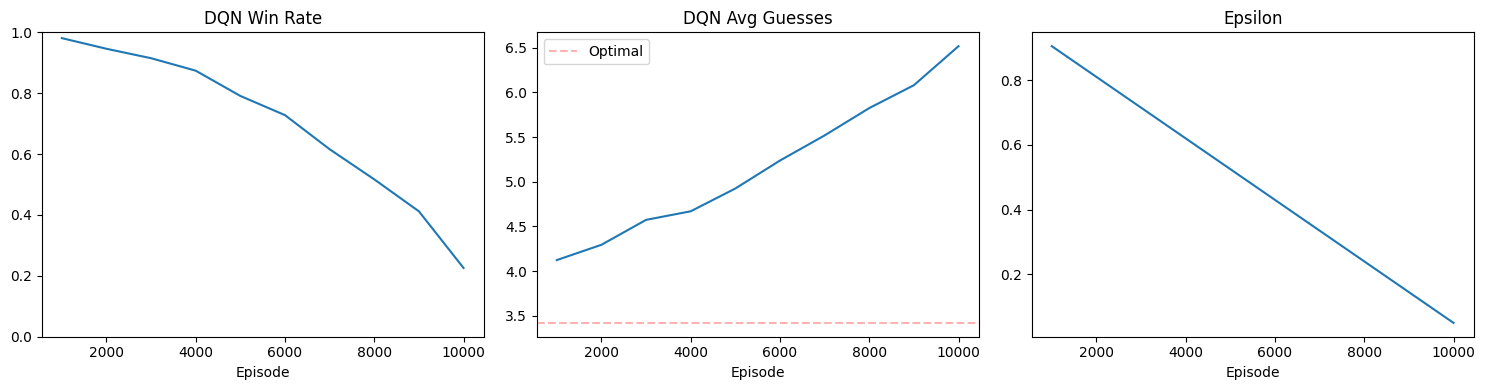

In [139]:
# DQN training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(dqn_history["episode"], dqn_history["win_rate"])
axes[0].set_title("DQN Win Rate")
axes[0].set_xlabel("Episode")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=1.0, color="r", linestyle="--", alpha=0.3)

axes[1].plot(dqn_history["episode"], dqn_history["avg_guesses"])
axes[1].set_title("DQN Avg Guesses")
axes[1].set_xlabel("Episode")
axes[1].axhline(y=3.421, color="r", linestyle="--", alpha=0.3, label="Optimal")
axes[1].legend()

axes[2].plot(dqn_history["episode"], dqn_history["epsilon"])
axes[2].set_title("Epsilon")
axes[2].set_xlabel("Episode")

plt.tight_layout()
plt.savefig("dqn_training.png", dpi=150)
plt.show()

In [140]:
dqn_solver = DQNSolver(model_path="models/dqn_model.pt")
demo_solver(dqn_solver)

Loaded DQN model from models/dqn_model.pt

Target: CRANE
  Turn 1: ICILY  ⬛ 🟨 ⬛ ⬛ ⬛
  Turn 2: HORDE  ⬛ ⬛ 🟨 ⬛ 🟩
  Turn 3: STUFF  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 4: SCOFF  ⬛ 🟨 ⬛ ⬛ ⬛
  Turn 5: SERVE  ⬛ ⬛ 🟨 ⬛ 🟩
  Turn 6: PIQUE  ⬛ ⬛ ⬛ ⬛ 🟩
  Failed! Target was CRANE

Target: SLINK
  Turn 1: ICILY  ⬛ ⬛ 🟩 🟨 ⬛
  Turn 2: STEAK  🟩 ⬛ ⬛ ⬛ 🟩
  Turn 3: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: NYMPH
  Turn 1: ICILY  ⬛ ⬛ ⬛ ⬛ 🟨
  Turn 2: ISLET  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 3: MARCH  🟨 ⬛ ⬛ ⬛ 🟩
  Turn 4: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: FUZZY
  Turn 1: ICILY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 2: IVORY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: SQUAT  ⬛ ⬛ 🟨 ⬛ ⬛
  Turn 4: MUMMY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 5: MUCKY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 6: EMCEE  ⬛ ⬛ ⬛ ⬛ ⬛
  Failed! Target was FUZZY

Target: VIVID
  Turn 1: ICILY  🟨 ⬛ 🟨 ⬛ ⬛
  Turn 2: SPIED  ⬛ ⬛ 🟨 ⬛ 🟩
  Turn 3: CAIRN  ⬛ ⬛ 🟨 ⬛ ⬛
  Turn 4: VIXEN  🟩 🟩 ⬛ ⬛ ⬛
  Turn 5: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!


---
## Part 4: Tabular Q-Learning (Meta-Strategy Learning)

This approach implements a tabular Q-learning agent that learns **which strategy to use**
at each stage of the game, rather than directly selecting words.

### Key Insight

Instead of learning over a large action space of ~3,000 words, the agent learns over a
small set of **predefined strategies**. This reduces the action space to just 5 options,
making tabular reinforcement learning feasible and stable.

---

### State Representation

The game state is encoded as:

- **(# green letters, # yellow letters)** from the previous guess

This provides a coarse measure of progress (“how close the guess is to the target”).
The resulting state space is small (~20–30 reachable states), allowing the use of a
compact Q-table.

---

### Strategy Set (Actions)

The agent chooses from five strategies:

1. **Random**  
   Select a random word from the remaining candidate set  

2. **Curated List**  
   Select from a predefined set of high-information exploratory words derived from
   early-game frequency solver behavior  

3. **Frequency**  
   Score remaining candidates using letter frequency and select the highest-scoring word  

4. **Smart (Constraint-Based)**  
   Apply all known constraints (green positions, yellow letters, gray exclusions) to
   filter candidates, then select the best word using frequency scoring  

5. **Exclude-Only**  
   Use only gray-letter exclusions to filter candidates (ignoring yellow positional
   constraints), then select using frequency scoring  

---

### Training

The agent plays simulated games and updates a Q-table using standard Q-learning with
epsilon-greedy exploration.

- **Episodes:** ~10,000 games  
- **Exploration rate (ε):** 0.3  
- **Update rule:** standard tabular Q-learning  

Over time, the Q-values estimate the expected return of each strategy in each state,
leading to a learned policy.

---

### Reward Structure

The reward function provides intermediate feedback and terminal rewards:

- **Green letter:** +5  
- **Yellow letter:** +2  
- **Win:** +25  
- **Loss:** −15  

This reward design is an implementation choice in this project, intended to balance
information gain during intermediate steps with successful task completion.

---

### Output

The learned policy is a compact lookup table mapping states to strategies, for example:

- (0 green, 0 yellow) → **Curated List**  
- (2 green, 1 yellow) → **Smart**  

This results in a simple, interpretable decision policy that adapts behavior across
different stages of the game.

---

### Interpretation

This method does not attempt to solve Wordle directly. Instead, it learns a
**meta-policy over heuristics**, leveraging strong predefined strategies while using
reinforcement learning to determine when each is most effective.

This is broadly aligned with the idea explored in Anderson & Meyer (2022): that effective
Wordle play can be achieved by adapting strategy based on game state, rather than relying
on a single fixed policy.

In [110]:
print("Training Tabular Q-Learning...")
start_time = time.time()

q_table, q_history = train_tabular_q(
    num_episodes=10000,
    alpha=0.02,
    gamma=0.05,
    epsilon=0.3,
    curated_words=set3,
    log_interval=1000
)

print(f"\nTabular Q training: {(time.time()-start_time)/60:.1f} minutes")

os.makedirs("models", exist_ok=True)
with open("models/q_table.pkl", "wb") as f:
    pickle.dump(q_table, f)
print("Saved to models/q_table.pkl")

Training Tabular Q-Learning...
  Episode 1000: win_rate=0.979, avg_guesses=3.97
  Episode 2000: win_rate=0.989, avg_guesses=3.86
  Episode 3000: win_rate=0.987, avg_guesses=3.83
  Episode 4000: win_rate=0.988, avg_guesses=3.82
  Episode 5000: win_rate=0.981, avg_guesses=3.84
  Episode 6000: win_rate=0.984, avg_guesses=3.79
  Episode 7000: win_rate=0.982, avg_guesses=3.79
  Episode 8000: win_rate=0.992, avg_guesses=3.74
  Episode 9000: win_rate=0.983, avg_guesses=3.84
  Episode 10000: win_rate=0.985, avg_guesses=3.85

Tabular Q training: 2.2 minutes
Saved to models/q_table.pkl


In [111]:
# Show learned policy
print("Learned policy:")
print(f"{'State':>12}  {'Best Strategy':>15}")
print("-" * 35)
for state in sorted(q_table.keys()):
    best = int(np.argmax(q_table[state]))
    print(f"  ({state[0]}g, {state[1]}y)  {STRATEGY_NAMES[best]:>15}")

Learned policy:
       State    Best Strategy
-----------------------------------
  (0g, 0y)            smart
  (0g, 1y)            smart
  (0g, 2y)            smart
  (0g, 3y)        frequency
  (0g, 4y)            smart
  (0g, 5y)           random
  (1g, 0y)        frequency
  (1g, 1y)            smart
  (1g, 2y)           random
  (1g, 3y)           random
  (1g, 4y)           random
  (2g, 0y)        frequency
  (2g, 1y)           random
  (2g, 2y)        frequency
  (2g, 3y)           random
  (3g, 0y)            smart
  (3g, 1y)            smart
  (3g, 2y)        frequency
  (4g, 0y)            smart


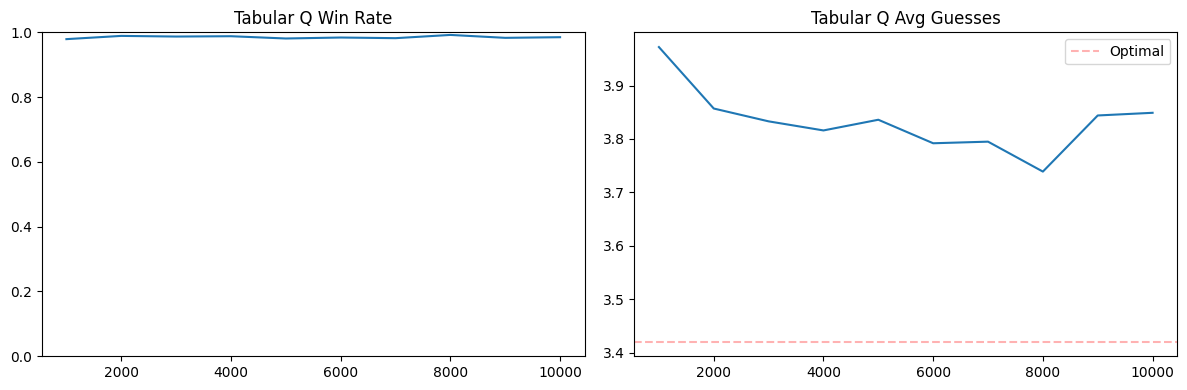

In [112]:
# Plot Q training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(q_history["episode"], q_history["win_rate"])
axes[0].set_title("Tabular Q Win Rate"); axes[0].set_ylim(0, 1)
axes[1].plot(q_history["episode"], q_history["avg_guesses"])
axes[1].set_title("Tabular Q Avg Guesses")
axes[1].axhline(y=3.421, color='r', linestyle='--', alpha=0.3, label='Optimal')
axes[1].legend()
plt.tight_layout(); plt.savefig("q_training.png", dpi=150); plt.show()

In [113]:
tq_solver = TabularQSolver(q_table_path="models/q_table.pkl")
demo_solver(tq_solver)

Loaded Q-table from models/q_table.pkl (19 states)
Loaded 1176 curated words

Target: CRANE
  Turn 1: ALERT  🟨 ⬛ 🟨 🟨 ⬛
  Turn 2: GRACE  ⬛ 🟩 🟩 🟨 🟩
  Turn 3: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: SLINK
  Turn 1: ALERT  ⬛ 🟩 ⬛ ⬛ ⬛
  Turn 2: SLUNK  🟩 🟩 ⬛ 🟩 🟩
  Turn 3: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: NYMPH
  Turn 1: ALERT  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: NOISY  🟩 ⬛ ⬛ ⬛ 🟨
  Turn 3: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: FUZZY
  Turn 1: ALERT  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: NOISY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: DUMPY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 4: BUGGY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 5: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: VIVID
  Turn 1: ALERT  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: NOISY  ⬛ ⬛ 🟨 ⬛ ⬛
  Turn 3: PUBIC  ⬛ ⬛ ⬛ 🟩 ⬛
  Turn 4: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!


---
## Part 5: Rollout (Bhambri et al., 2022)

This solver implements a **rollout / one-step lookahead** method inspired by Bhambri,
Bhattacharjee, and Bertsekas (2022), who frame Wordle as a sequential decision problem and
apply approximate dynamic programming via policy improvement.

The core idea is to improve a base heuristic by evaluating the **expected downstream
cost** of each candidate guess using one-step lookahead.

---

### Core Idea

At any turn, the game state is the set of remaining candidate words, denoted by $S$.

For each candidate guess $g$, the solver considers all possible hidden words
$w \in S$. Each hidden word produces a feedback pattern, which determines a new reduced
candidate set $S'$.

Instead of selecting a guess based only on immediate statistics, rollout evaluates:

> If I play guess $g$ now, and then follow my base policy, how many total guesses will I
> need on average?

Formally, the rollout value of a guess $g$ is:

$$
Q(g) = \frac{1}{|S|} \sum_{w \in S} \text{cost}(g, w)
$$

and the selected guess is:

$$
g^* = \arg\min_g Q(g)
$$

This is a **one-step policy improvement**: it uses the base heuristic to approximate future
costs, while explicitly optimizing the current decision.

---

### Why this is Dynamic Programming in Practice

This method naturally forms a **dynamic programming structure**:

- The subproblem is: “given a candidate set $S$, what is the best next guess?”
- Many different game paths lead to the same $S$
- Once solved, the result for $S$ can be reused

With memoization, rollout becomes:

- **Without caching:** repeated forward simulation  
- **With caching:** a DP-style lookup over visited states  

In practice, this behaves like a **memoized approximate dynamic program** over reachable
candidate sets.

---

### Candidate Selection (Top-$N$ Restriction)

Evaluating rollout over all possible guesses is expensive. Following Bhambri et al., the
solver restricts evaluation to a small set of promising candidates:

1. Score all words using a fast heuristic  
2. Select the top $N$ candidates (e.g., $N = 10$)  
3. Run full rollout evaluation only on those candidates  

This preserves most of the benefit of rollout while keeping computation tractable.

---

### Base Policy

Rollout improves a **base policy**, which is used to simulate future play.

In this implementation, the base policy is the frequency heuristic, with an additional
practical refinement:

- **frequency scoring** when the remaining set is large  
- **minimax-style partition scoring** when the remaining set is small  

This is a project-specific engineering choice inspired by the rollout framework, but not a
direct reproduction of the exact setup in Bhambri et al.

---

### Detailed Mechanics in This Implementation

At each turn, the solver proceeds as follows:

1. Let $S$ be the current set of remaining candidate words.  
2. Generate a short list of promising guesses using a fast scoring rule.  
3. For each candidate guess $g$ in that short list:
   - simulate feedback against **every** hidden word $w \in S$  
   - apply the resulting feedback to produce the next candidate set $S'$  
   - if $S'$ is already cached, reuse the stored best action / cost  
   - otherwise, continue by following the base policy from $S'$  
   - record the total number of guesses needed to solve each case  
4. Average those totals across all $w \in S$  
5. Choose the guess with minimum average total cost  

---

### Relationship to Minimax

- **Minimax** optimizes the **worst-case** next partition size  
- **Rollout** optimizes the **expected** total solving cost  

Minimax is conservative and guards against the worst outcome. Rollout instead optimizes
average performance, often achieving fewer guesses overall.

---

### Cache / Memoization

Results are memoized to disk (e.g., `models/rollout_cache.pkl`), mapping each visited
candidate set to its optimal next action.

On the 2,983-word benchmark, this process resulted in **431 unique visited states**.
This reflects the number of distinct candidate sets encountered during rollout evaluation
in this implementation.

Once cached, evaluation becomes effectively instantaneous.

---

### Interpretation

This method is best understood as a **memoized approximate dynamic programming approach**:

- It is not exact dynamic programming over the full game tree  
- It is a DP-style policy improvement method with overlapping subproblems  
- In practice, it behaves like a dynamic program over reachable candidate sets  

This combination of structured lookahead and memoization is what allows rollout to achieve
near-optimal performance in Wordle-like environments.

In [114]:
rollout_solver = RolloutSolver(top_k=10)
demo_solver(rollout_solver)

Loaded rollout cache: 9767 states from /content/wordle-ML-project/models/rollout_cache.pkl

Target: CRANE
  Turn 1: SLATE  ⬛ ⬛ 🟩 ⬛ 🟩
  Turn 2: PRICK  ⬛ 🟩 ⬛ 🟨 ⬛
  Turn 3: ANVIL  🟨 🟨 ⬛ ⬛ ⬛
  Turn 4: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: SLINK
  Turn 1: SLATE  🟩 🟩 ⬛ ⬛ ⬛
  Turn 2: HUNKY  ⬛ ⬛ 🟨 🟨 ⬛
  Turn 3: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: NYMPH
  Turn 1: SLATE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: CRONY  ⬛ ⬛ ⬛ 🟨 🟨
  Turn 3: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: FUZZY
  Turn 1: SLATE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: CRONY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: DUMPY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 4: BUGGY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 5: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: VIVID
  Turn 1: SLATE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: CRONY  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 3: HUMID  ⬛ ⬛ ⬛ 🟩 🟩
  Turn 4: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!


---
## Part 6: DQN v2 — Teacher-Guided (Reward-Shaped)

DQN v1 showed that a pure deep RL approach struggles in this environment. As exploration
decreases, the model's own decisions begin to dominate training data. If those decisions
are poor, the replay buffer fills with low-quality trajectories, which can degrade
learning over time (a form of policy-induced distribution shift).

Empirically, the learned policy in v1 underperformed even simple baselines, suggesting
that the model did not develop a strong internal representation of what makes a guess
informative.

---

### Diagnosis

The primary issue is **exploration quality**.

- Random exploration covers the space but produces mostly uninformative trajectories  
- The model rarely observes what good play looks like during training  
- Once epsilon decays, the model's weak policy generates poor data, which makes the
  policy worse — a death spiral  

This is a known challenge in RL: exploration must not only cover the space, but also
produce **useful training signals**.

---

### Approach: Teacher-Guided Learning

DQN v2 introduces a **teacher-guided training strategy**, using the rollout solver as a
high-quality policy to guide learning.

Rather than relying on random exploration, the agent observes and partially imitates a
strong policy during training. This results in a hybrid approach combining:

- reinforcement learning (value estimation)  
- imitation learning (learning from demonstrations)  

---

### Key Modifications from v1

#### 1. Teacher-Guided Exploration

When exploring (with probability $\epsilon$), the agent follows the rollout solver's
recommended action instead of selecting a random guess.

This ensures that:

- exploration trajectories are high-quality  
- the replay buffer contains useful state-action examples  
- training is anchored to a strong reference policy  

The teacher guides all turns, including the opener. There are no forced curated openings
or restricted word sets — the model learns entirely from the teacher and its own policy.

---

#### 2. Reward Shaping Toward Teacher Policy

An additional reward bonus is given when the model selects the same action as the teacher:

- **Match teacher action:** +20 bonus  

For context, solving the game on turn 1 yields +20 from the base reward. Matching the
teacher on a single turn carries equivalent weight, creating a strong gradient toward
teacher-aligned behavior, especially in states where tile feedback alone is ambiguous.

---

#### 3. Exploration Schedule

- $\epsilon$ decays linearly from **1.0 → 0.05** over 20,000 episodes  
- Early training is dominated by teacher demonstrations  
- Late training tests whether the model has internalized the teacher's strategy  

---

#### 4. Expanded Rollout Cache

The rollout solver is memoized. During training:

- initial cache contains states encountered during precomputation  
- additional states are added as the DQN explores off-policy trajectories  

This allows the teacher to provide guidance even in previously unseen states.

---

### Architecture and Stability

The model architecture is unchanged from DQN v1:

- **Input:** 417-dimensional state vector  
- **Hidden layers:** 512 → 512 fully connected layers  
- **Output:** 130-dimensional factorized representation  
- **Action scoring:** dot product with word encodings  

Training uses the same stability techniques as v1: Double DQN, gradient clipping
(max norm 1.0), experience replay (100,000 transitions), target network synchronization
every 500 episodes, and guess masking to prevent repeat guesses. All improvements over
v1 come from changes to the training process rather than model structure.

---

### Training Setup

- **Episodes:** 20,000  
- **Replay buffer:** 100,000 transitions  
- **Target network:** synchronized every 500 episodes  
- **Compute cost:** significantly higher than v1 due to rollout evaluation at each step  

---

### Interpretation

This method should be viewed as a **hybrid RL + imitation learning approach**:

- RL provides a value-learning framework  
- The rollout solver provides high-quality supervision  
- Reward shaping aligns the learned policy with the teacher  

The goal is not to exceed the rollout solver, but to **approximate its policy using a
neural network**.

---

### Key Insight

Even with strong teacher guidance, performance is constrained by:

- the factorized action representation  
- the difficulty of approximating structured logical reasoning with a neural network  

This highlights an important result of the project:

> In structured, fully observable environments like Wordle, learning from demonstration
> can improve stability, but explicit search-based methods remain more reliable than
> learned value-function approximations.

In [141]:
def train_dqn_v2(num_episodes=20000, batch_size=64, gamma=0.95,
                 lr=0.001, target_update=500, log_interval=1000,
                 rollout_solver=None, teacher_bonus=20.0):
    """
    DQN v2: teacher-guided training using rollout as a strong policy.

    Same architecture and training loop as DQN v1, with two additions:
        - When exploring, the agent follows the rollout solver's action
          instead of picking randomly (high-quality trajectories)
        - When exploiting, the agent gets a large bonus (+20) for matching
          the teacher's recommended action (strong imitation signal)

    Uses Double DQN, gradient clipping, and guess masking like v1.
    """
    if rollout_solver is None:
        raise ValueError("train_dqn_v2 requires rollout_solver")

    word_to_idx = {w: i for i, w in enumerate(WORDS)}
    policy_net = DQNNetwork().to(device)
    target_net = DQNNetwork().to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(capacity=100000)
    word_enc = WORD_ENCODINGS.to(device)

    history = {"episode": [], "win_rate": [], "avg_guesses": [], "epsilon": []}
    recent_wins = []
    recent_guesses = []

    epsilon_start = 1.0
    epsilon_end = 0.05
    cache_before = len(rollout_solver.cache)

    for episode in range(num_episodes):
        target = random.choice(WORDS)
        game = WordleGame(target=target, word_list=WORDS)
        guesses, feedbacks_list = [], []
        remaining = list(WORDS)

        rollout_solver.reset()

        # Linear epsilon decay
        epsilon = epsilon_start - (epsilon_start - epsilon_end) * (episode / num_episodes)

        while not game.is_over():
            state = encode_state(guesses, feedbacks_list, game.turn)
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

            # Ask the teacher what it would do in this state
            teacher_guess = None
            if len(remaining) > 1:
                game_state = {
                    "guesses": list(guesses),
                    "feedbacks": list(feedbacks_list),
                }
                teacher_guess = rollout_solver.get_guess(game_state=game_state)

            if random.random() < epsilon:
                # Explore: follow the teacher (not random)
                if teacher_guess is not None:
                    guess = teacher_guess
                else:
                    guess = remaining[0]
                action_idx = word_to_idx[guess]
            else:
                # Exploit: model picks, with guess masking
                with torch.no_grad():
                    output = policy_net(state_t)
                    scores = torch.matmul(output, word_enc.T).squeeze(0)

                for g in guesses:
                    if g in word_to_idx:
                        scores[word_to_idx[g]] = -float("inf")

                action_idx = scores.argmax().item()
                guess = WORDS[action_idx]

            feedback = game.make_guess(guess)
            guesses.append(guess)
            feedbacks_list.append(feedback)
            remaining = filter_words(remaining, guess, feedback)

            solved = game.is_solved()
            failed = game.turn >= 6 and not solved
            reward = compute_reward(feedback, solved, failed, game.turn)

            # Big bonus for matching the teacher's pick
            if teacher_guess is not None and guess == teacher_guess:
                reward += teacher_bonus

            next_state = encode_state(guesses, feedbacks_list, game.turn)
            done = solved or failed

            replay_buffer.push(state, action_idx, reward, next_state, done)

            if len(replay_buffer) >= batch_size:
                s_b, a_b, r_b, ns_b, d_b = replay_buffer.sample(batch_size)
                s_b, a_b, r_b = s_b.to(device), a_b.to(device), r_b.to(device)
                ns_b, d_b = ns_b.to(device), d_b.to(device)

                # Current Q-values for chosen actions
                out = policy_net(s_b)
                q_vals = torch.matmul(out, word_enc.T).gather(1, a_b.unsqueeze(1)).squeeze(1)

                # Double DQN: policy net picks the action, target net evaluates it
                with torch.no_grad():
                    next_scores = torch.matmul(policy_net(ns_b), word_enc.T)
                    next_actions = next_scores.argmax(dim=1)
                    next_q = torch.matmul(target_net(ns_b), word_enc.T) \
                                  .gather(1, next_actions.unsqueeze(1)).squeeze(1)
                    target_q = r_b + gamma * next_q * (1 - d_b)

                loss = F.mse_loss(q_vals, target_q)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)
                optimizer.step()

            if done:
                break

        # Sync target network
        if episode % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())

        # Checkpoint
        if (episode + 1) % 5000 == 0:
            torch.save(policy_net.state_dict(), f"models/dqn_v2_ep{episode+1}.pt")

        # Track metrics
        recent_wins.append(1 if game.is_solved() else 0)
        recent_guesses.append(game.turn if game.is_solved() else 7)
        if len(recent_wins) > 1000:
            recent_wins.pop(0)
            recent_guesses.pop(0)

        if (episode + 1) % log_interval == 0:
            wr = sum(recent_wins) / len(recent_wins)
            ag = sum(recent_guesses) / len(recent_guesses)
            cache_size = len(rollout_solver.cache)
            history["episode"].append(episode + 1)
            history["win_rate"].append(wr)
            history["avg_guesses"].append(ag)
            history["epsilon"].append(epsilon)
            print(
                f"  Ep {episode+1}: win={wr:.3f}, avg={ag:.2f}, "
                f"eps={epsilon:.3f}, cache={cache_size}"
            )

    cache_after = len(rollout_solver.cache)
    print(f"\nCache grew: {cache_before} → {cache_after} states (+{cache_after - cache_before})")
    rollout_solver.save_cache()

    return policy_net, history

In [142]:
# Load rollout solver with existing cache
rollout_solver = RolloutSolver(top_k=10)

print(f"Starting cache: {len(rollout_solver.cache)} states")
print("Training DQN v2 (teacher-guided with rollout, Double DQN)...")
start_time = time.time()

dqn_v2_model, dqn_v2_history = train_dqn_v2(
    num_episodes=20000,
    rollout_solver=rollout_solver,
    teacher_bonus=20.0,
    log_interval=1000
)

print(f"\nDQN v2 training: {(time.time() - start_time) / 60:.1f} minutes")

os.makedirs("models", exist_ok=True)
torch.save(dqn_v2_model.state_dict(), "models/dqn_v2_model.pt")
print("Saved to models/dqn_v2_model.pt")

Loaded rollout cache: 17840 states from /content/wordle-ML-project/models/rollout_cache.pkl
Starting cache: 17840 states
Training DQN v2 (teacher-guided with rollout, Double DQN)...
  Ep 1000: win=0.999, avg=3.56, eps=0.953, cache=17892
  Ep 2000: win=0.999, avg=3.59, eps=0.905, cache=17963
  Ep 3000: win=0.996, avg=3.69, eps=0.858, cache=18087
  Ep 4000: win=0.996, avg=3.73, eps=0.810, cache=18174
  Ep 5000: win=0.983, avg=3.85, eps=0.763, cache=18293
  Ep 6000: win=0.978, avg=3.92, eps=0.715, cache=18378
  Ep 7000: win=0.967, avg=4.06, eps=0.668, cache=18507
  Ep 8000: win=0.955, avg=4.09, eps=0.620, cache=18626
  Ep 9000: win=0.943, avg=4.25, eps=0.573, cache=18709
  Ep 10000: win=0.929, avg=4.22, eps=0.525, cache=18766
  Ep 11000: win=0.887, avg=4.43, eps=0.478, cache=18849
  Ep 12000: win=0.854, avg=4.55, eps=0.430, cache=18926
  Ep 13000: win=0.813, avg=4.70, eps=0.383, cache=18985
  Ep 14000: win=0.784, avg=4.79, eps=0.335, cache=19036
  Ep 15000: win=0.750, avg=4.89, eps=0.288,

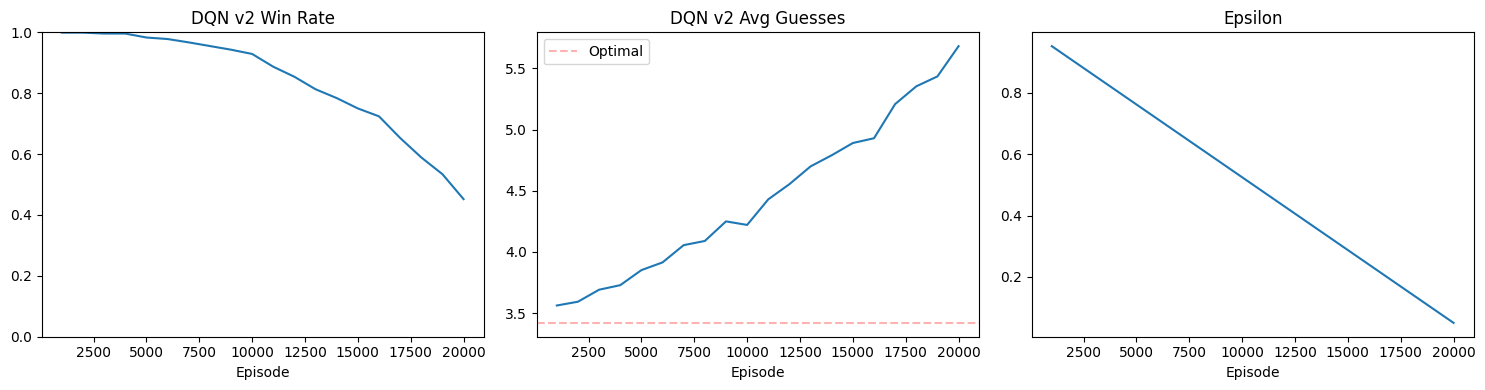

In [143]:
# DQN v2 training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(dqn_v2_history["episode"], dqn_v2_history["win_rate"])
axes[0].set_title("DQN v2 Win Rate")
axes[0].set_xlabel("Episode")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=1.0, color="r", linestyle="--", alpha=0.3)

axes[1].plot(dqn_v2_history["episode"], dqn_v2_history["avg_guesses"])
axes[1].set_title("DQN v2 Avg Guesses")
axes[1].set_xlabel("Episode")
axes[1].axhline(y=3.421, color="r", linestyle="--", alpha=0.3, label="Optimal")
axes[1].legend()

axes[2].plot(dqn_v2_history["episode"], dqn_v2_history["epsilon"])
axes[2].set_title("Epsilon")
axes[2].set_xlabel("Episode")

plt.tight_layout()
plt.savefig("dqn_v2_training.png", dpi=150)
plt.show()

In [144]:
dqn_v2_solver = DQNSolver(model_path="models/dqn_v2_model.pt")
demo_solver(dqn_v2_solver)

Loaded DQN model from models/dqn_v2_model.pt

Target: CRANE
  Turn 1: SLATE  ⬛ ⬛ 🟩 ⬛ 🟩
  Turn 2: PRICK  ⬛ 🟩 ⬛ 🟨 ⬛
  Turn 3: BRACE  ⬛ 🟩 🟩 🟨 🟩
  Turn 4: CRATE  🟩 🟩 🟩 ⬛ 🟩
  Turn 5: FEVER  ⬛ 🟨 ⬛ ⬛ 🟨
  Turn 6: JERKY  ⬛ 🟨 🟨 ⬛ ⬛
  Failed! Target was CRANE

Target: SLINK
  Turn 1: SLATE  🟩 🟩 ⬛ ⬛ ⬛
  Turn 2: HUNKY  ⬛ ⬛ 🟨 🟨 ⬛
  Turn 3: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: NYMPH
  Turn 1: SLATE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: CRONY  ⬛ ⬛ ⬛ 🟨 🟨
  Turn 3: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: FUZZY
  Turn 1: SLATE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: CRONY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: DUMPY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 4: BUGGY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 5: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: VIVID
  Turn 1: SLATE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: CRONY  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 3: HUMID  ⬛ ⬛ ⬛ 🟩 🟩
  Turn 4: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!


---
## Part 7: Evaluation — All Six Solvers

Run each solver against every word. Measure win rate, average guesses, distribution.

In [119]:
def evaluate_solver(solver, words, name="Solver", max_words=None):
    test_words = words[:max_words] if max_words else words
    results = []
    for target in tqdm(test_words, desc=name):
        game = WordleGame(target=target, word_list=words)
        solver.reset()
        while not game.is_over():
            guess = solver.get_guess()
            feedback = game.make_guess(guess)
            solver.update(guess, feedback)
            if game.is_solved(): break
        guesses_used = game.turn if game.is_solved() else 7
        results.append({"word": target, "guesses": guesses_used, "solved": game.is_solved()})

    guess_counts = [r["guesses"] for r in results]
    solved_counts = [r["guesses"] for r in results if r["solved"]]
    return {
        "name": name, "total_words": len(test_words),
        "solved": sum(1 for r in results if r["solved"]),
        "win_rate": sum(1 for r in results if r["solved"]) / len(test_words),
        "avg_guesses": np.mean(solved_counts) if solved_counts else float('inf'),
        "avg_guesses_all": np.mean(guess_counts),
        "max_guesses": max(guess_counts), "min_guesses": min(guess_counts),
        "distribution": guess_counts, "results": results
    }

def print_summary(s):
    print(f"\n{'='*50}")
    print(f"  {s['name']}")
    print(f"{'='*50}")
    print(f"  Words tested:    {s['total_words']}")
    print(f"  Solved:          {s['solved']} ({s['win_rate']*100:.1f}%)")
    print(f"  Avg guesses:     {s['avg_guesses']:.3f} (solved only)")
    print(f"  Avg guesses:     {s['avg_guesses_all']:.3f} (all, 7=fail)")
    print(f"  Min guesses:     {s['min_guesses']}")
    print(f"  Max guesses:     {s['max_guesses']}")
    dist = Counter(s['distribution'])
    print(f"\n  Distribution:")
    for k in sorted(dist.keys()):
        label = f"{k}" if k <= 6 else "7+ (fail)"
        bar = "█" * (dist[k] * 40 // s['total_words'])
        print(f"    {label:>10}: {dist[k]:>5} ({dist[k]/s['total_words']*100:5.1f}%) {bar}")

In [120]:
MAX_WORDS = None  # Set to 50 for quick test, None for full eval
all_results = {}

In [121]:
# Solver 1: Frequency Heuristic
freq_solver = FrequencySolver()
all_results["frequency"] = evaluate_solver(freq_solver, WORDS, "Frequency Heuristic", MAX_WORDS)
print_summary(all_results["frequency"])

Frequency Heuristic: 100%|██████████| 2315/2315 [01:58<00:00, 19.54it/s]


  Frequency Heuristic
  Words tested:    2315
  Solved:          2314 (100.0%)
  Avg guesses:     3.575 (solved only)
  Avg guesses:     3.576 (all, 7=fail)
  Min guesses:     1
  Max guesses:     7

  Distribution:
             1:     1 (  0.0%) 
             2:   115 (  5.0%) █
             3:   974 ( 42.1%) ████████████████
             4:  1014 ( 43.8%) █████████████████
             5:   197 (  8.5%) ███
             6:    13 (  0.6%) 
     7+ (fail):     1 (  0.0%) 


In [122]:
# Solver 2: Information Gain
ig_solver = InfoGainSolver()
all_results["infogain"] = evaluate_solver(ig_solver, WORDS, "Information Gain", MAX_WORDS)
print_summary(all_results["infogain"])

Computing best opening guess (one-time cost)...
  Best opener: RAISE (13.8s)


Information Gain: 100%|██████████| 2315/2315 [14:57<00:00,  2.58it/s]


  Information Gain
  Words tested:    2315
  Solved:          2315 (100.0%)
  Avg guesses:     3.644 (solved only)
  Avg guesses:     3.644 (all, 7=fail)
  Min guesses:     1
  Max guesses:     5

  Distribution:
             1:     1 (  0.0%) 
             2:    58 (  2.5%) █
             3:   828 ( 35.8%) ██████████████
             4:  1305 ( 56.4%) ██████████████████████
             5:   123 (  5.3%) ██


In [145]:
# Solver 3: DQN
dqn_solver = DQNSolver(model_path="models/dqn_model.pt")
all_results["dqn"] = evaluate_solver(dqn_solver, WORDS, "DQN", MAX_WORDS)
print_summary(all_results["dqn"])

Loaded DQN model from models/dqn_model.pt


DQN: 100%|██████████| 2315/2315 [00:20<00:00, 114.44it/s]


  DQN
  Words tested:    2315
  Solved:          1556 (67.2%)
  Avg guesses:     4.582 (solved only)
  Avg guesses:     5.375 (all, 7=fail)
  Min guesses:     1
  Max guesses:     7

  Distribution:
             1:     1 (  0.0%) 
             2:    27 (  1.2%) 
             3:   203 (  8.8%) ███
             4:   477 ( 20.6%) ████████
             5:   530 ( 22.9%) █████████
             6:   318 ( 13.7%) █████
     7+ (fail):   759 ( 32.8%) █████████████


In [124]:
# Solver 4: Tabular Q
tq_solver = TabularQSolver(q_table_path="models/q_table.pkl")
all_results["tabular_q"] = evaluate_solver(tq_solver, WORDS, "Tabular Q-Learning", MAX_WORDS)
print_summary(all_results["tabular_q"])

Loaded Q-table from models/q_table.pkl (19 states)
Loaded 1176 curated words


Tabular Q-Learning: 100%|██████████| 2315/2315 [00:32<00:00, 70.50it/s]


  Tabular Q-Learning
  Words tested:    2315
  Solved:          2292 (99.0%)
  Avg guesses:     3.651 (solved only)
  Avg guesses:     3.685 (all, 7=fail)
  Min guesses:     1
  Max guesses:     7

  Distribution:
             1:     1 (  0.0%) 
             2:   135 (  5.8%) ██
             3:   910 ( 39.3%) ███████████████
             4:   925 ( 40.0%) ███████████████
             5:   258 ( 11.1%) ████
             6:    63 (  2.7%) █
     7+ (fail):    23 (  1.0%) 


In [125]:
# Solver 5: Rollout
rollout_solver = RolloutSolver(top_k=10)
all_results["rollout"] = evaluate_solver(rollout_solver, WORDS, "Rollout", MAX_WORDS)
print_summary(all_results["rollout"])

# Save cache for future runs
rollout_solver.save_cache()
print(rollout_solver.cache_stats())

Loaded rollout cache: 17840 states from /content/wordle-ML-project/models/rollout_cache.pkl


Rollout: 100%|██████████| 2315/2315 [00:12<00:00, 182.66it/s]



  Rollout
  Words tested:    2315
  Solved:          2315 (100.0%)
  Avg guesses:     3.477 (solved only)
  Avg guesses:     3.477 (all, 7=fail)
  Min guesses:     1
  Max guesses:     6

  Distribution:
             1:     1 (  0.0%) 
             2:    89 (  3.8%) █
             3:  1121 ( 48.4%) ███████████████████
             4:  1014 ( 43.8%) █████████████████
             5:    89 (  3.8%) █
             6:     1 (  0.0%) 
Saved rollout cache: 17840 states to /content/wordle-ML-project/models/rollout_cache.pkl
Cache: 17840 states, 5603 hits / 0 misses (100.0% hit rate)


In [146]:
# Solver 6: DQN v2 (Reward Shaped)
dqn_v2_solver = DQNSolver(model_path="models/dqn_v2_model.pt")
all_results["dqn_v2"] = evaluate_solver(dqn_v2_solver, WORDS, "DQN v2 (Shaped)", MAX_WORDS)
print_summary(all_results["dqn_v2"])

Loaded DQN model from models/dqn_v2_model.pt


DQN v2 (Shaped): 100%|██████████| 2315/2315 [00:17<00:00, 135.64it/s]


  DQN v2 (Shaped)
  Words tested:    2315
  Solved:          2261 (97.7%)
  Avg guesses:     3.678 (solved only)
  Avg guesses:     3.756 (all, 7=fail)
  Min guesses:     1
  Max guesses:     7

  Distribution:
             1:     1 (  0.0%) 
             2:    73 (  3.2%) █
             3:   963 ( 41.6%) ████████████████
             4:   917 ( 39.6%) ███████████████
             5:   229 (  9.9%) ███
             6:    78 (  3.4%) █
     7+ (fail):    54 (  2.3%) 


---
## Part 8: Comparison & Visualization

In [147]:
solver_keys = ["frequency", "infogain", "dqn", "tabular_q", "rollout", "dqn_v2"]

print(f"\n{'Solver':<25} {'Win Rate':>10} {'Avg Guesses':>12} {'Max':>5}")
print("-" * 55)
for key in solver_keys:
    r = all_results[key]
    print(f"{r['name']:<25} {r['win_rate']*100:>9.1f}% {r['avg_guesses']:>12.3f} {r['max_guesses']:>5}")
print("-" * 55)
print(f"{'Optimal (Bertsimas)':<25} {'100.0%':>10} {'3.421':>12} {'5':>5}")


Solver                      Win Rate  Avg Guesses   Max
-------------------------------------------------------
Frequency Heuristic           100.0%        3.575     7
Information Gain              100.0%        3.644     5
DQN                            67.2%        4.582     7
Tabular Q-Learning             99.0%        3.651     7
Rollout                       100.0%        3.477     6
DQN v2 (Shaped)                97.7%        3.678     7
-------------------------------------------------------
Optimal (Bertsimas)           100.0%        3.421     5


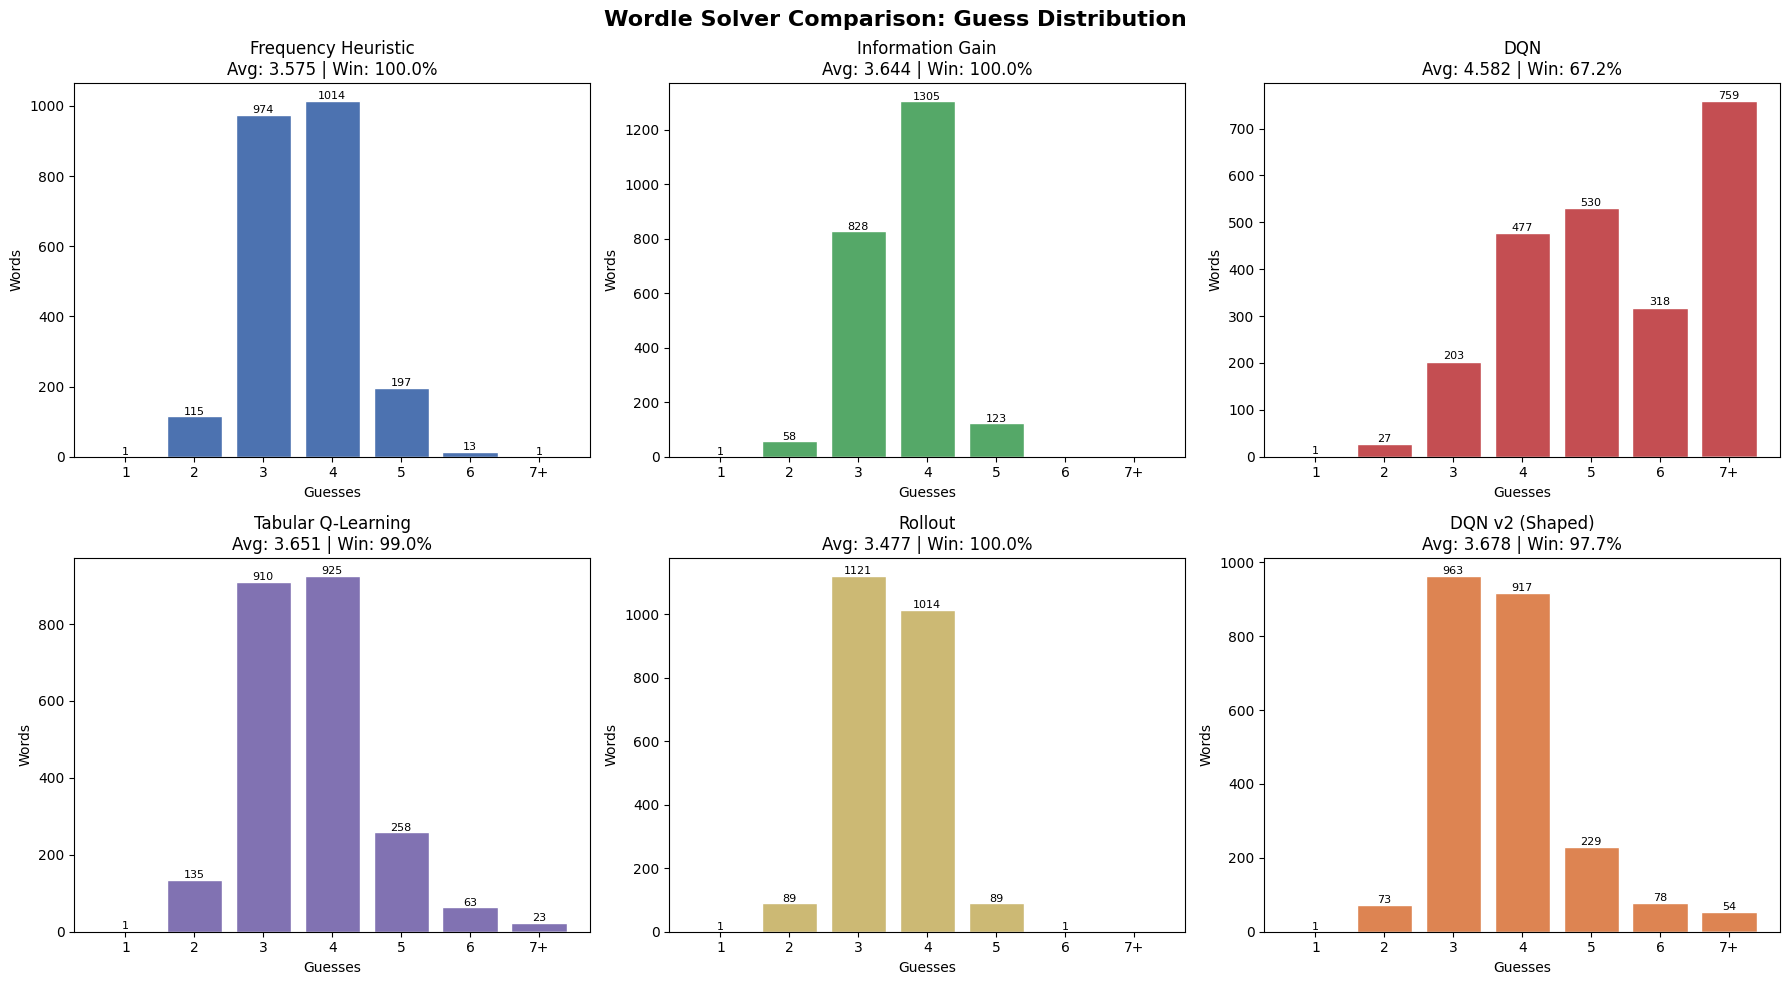

In [148]:
# Individual histograms
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Wordle Solver Comparison: Guess Distribution", fontsize=16, fontweight='bold')
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#DD8452"]

for ax, key, color in zip(axes.flat[:6], solver_keys, colors):
    r = all_results[key]
    bins = range(1, 9)
    counts = [r["distribution"].count(i) for i in bins]
    labels = [str(i) if i <= 6 else "7+" for i in bins]
    ax.bar(labels, counts, color=color, edgecolor='white')
    for bar, c in zip(ax.patches, counts):
        if c > 0: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(c), ha='center', fontsize=8)
    ax.set_title(f"{r['name']}\nAvg: {r['avg_guesses']:.3f} | Win: {r['win_rate']*100:.1f}%")
    ax.set_xlabel("Guesses"); ax.set_ylabel("Words")

plt.tight_layout(); plt.savefig("solver_comparison.png", dpi=150); plt.show()

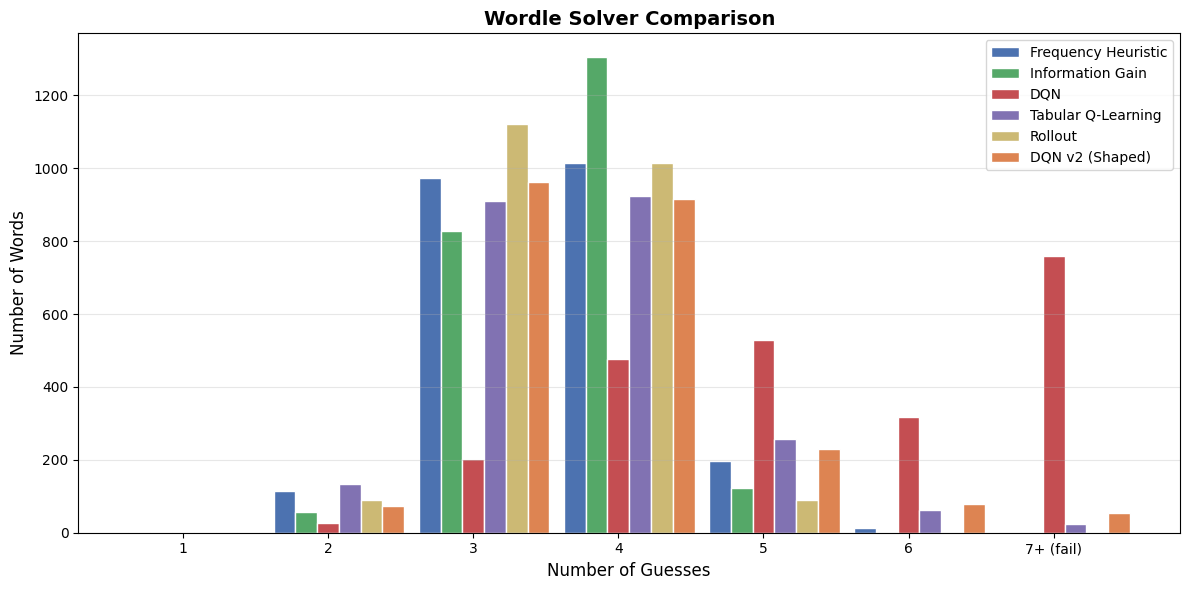

In [150]:
# Overlaid comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(1, 8)
width = 0.15
for i, (key, color) in enumerate(zip(solver_keys, colors)):
    r = all_results[key]
    counts = [r["distribution"].count(g) for g in range(1, 8)]
    offset = (i - 2) * width
    ax.bar(x + offset, counts, width, label=r["name"], color=color, edgecolor='white')

ax.set_xlabel("Number of Guesses", fontsize=12)
ax.set_ylabel("Number of Words", fontsize=12)
ax.set_title("Wordle Solver Comparison", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(i) if i <= 6 else "7+ (fail)" for i in range(1, 8)])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig("solver_overlay.png", dpi=150); plt.show()

In [151]:
# Hardest words per solver
print("\nHardest words (most guesses) per solver:")
print("=" * 60)
for key in solver_keys:
    r = all_results[key]
    worst = sorted(r["results"], key=lambda x: -x["guesses"])
    print(f"\n{r['name']}:")
    for item in worst[:5]:
        s = "FAIL" if not item["solved"] else f"{item['guesses']} guesses"
        print(f"  {item['word'].upper():>8} — {s}")


Hardest words (most guesses) per solver:

Frequency Heuristic:
     ROGER — FAIL
     BOXER — 6 guesses
     FERRY — 6 guesses
     FOUND — 6 guesses
     FREER — 6 guesses

Information Gain:
     BALER — 5 guesses
     BATCH — 5 guesses
     BERRY — 5 guesses
     BEZEL — 5 guesses
     BILLY — 5 guesses

DQN:
     ABASE — FAIL
     ABATE — FAIL
     ABLED — FAIL
     ABUSE — FAIL
     ADAGE — FAIL

Tabular Q-Learning:
     CATCH — FAIL
     CRAZY — FAIL
     FOYER — FAIL
     GONER — FAIL
     HATCH — FAIL

Rollout:
     JOKER — 6 guesses
     BELLY — 5 guesses
     BOOZY — 5 guesses
     BOUND — 5 guesses
     BOXER — 5 guesses

DQN v2 (Shaped):
     BRAWN — FAIL
     CHARD — FAIL
     CRACK — FAIL
     CRAMP — FAIL
     CRANE — FAIL


---
## Summary

| Solver | Type | Win Rate | Avg Guesses | Speed (it/s) | Reference |
|--------|------|----------|-------------|--------------|-----------|
| **Optimal** | **Exact DP** | **100.0%** | **3.421** | **—** | **Bertsimas & Paskov (2024)** |
| Rollout | DP/Lookahead | 100.0% | 3.477 | 182.66 | Bhambri et al. (2022) |
| Frequency Heuristic | Heuristic | 100.0% | 3.575 | 19.54 | Baseline (original, 2021) |
| Information Gain | Heuristic | 100.0% | 3.644 | 2.58 | Liu (2022) |
| Tabular Q-Learning | RL | 99.0% | 3.651 | 70.50 | Anderson & Meyer (2022) |
| **DQN v2 (Teacher-Guided)** | **Deep RL** | **97.7%** | **3.678** | **135.64** | **Ho (2022) + rollout teacher** |
| DQN v1 (Pure) | Deep RL | 67.2% | 4.582 | 114.44 | Ho (2022) |
| *Ho (2022) reported* | *Deep RL* | *~98%* | *~4.1* | *—* | *Ho (2022)* |

DQN v2 surpassed Ho's reported deep RL results (4.1 average guesses, ~98% win rate),
achieving 3.678 average guesses — a reduction of approximately 0.4 guesses per game —
while using a simpler single-phase training setup with Double DQN and teacher-guided
exploration.

---
## Final Summary and Discussion

This project compared multiple solver paradigms for Wordle using a unified 2,315-word
closed-vocabulary benchmark. The results show a clear hierarchy of performance driven not
by model complexity, but by how well each method aligns with the underlying structure of
the problem.

### Main Findings

- **Planning-based methods performed best.**  
  The strongest approach in this project was the rollout solver, a memoized lookahead
  planner based on approximate dynamic programming. It achieved near-optimal performance
  (3.477 average guesses, 100% win rate), closely approaching the exact dynamic
  programming result of Bertsimas & Paskov (3.421 average).

- **Expected-value lookahead outperformed worst-case heuristics.**  
  The rollout method consistently outperformed the minimax-style solver, indicating that
  optimizing expected future cost is more effective than optimizing worst-case partitions
  for this problem.

- **Simple heuristics were highly competitive.**  
  The original frequency heuristic achieved 100% win rate with 3.575 average guesses,
  demonstrating that well-designed heuristics can capture much of the structure of the
  problem without explicit search.

- **Meta-strategy reinforcement learning was effective.**  
  Tabular Q-learning achieved 99.0% win rate by learning a **policy over strategies**
  rather than directly over words. Reducing the action space made learning stable and
  interpretable.

- **Pure deep RL struggled, but teacher-guided deep RL was competitive.**  
  DQN v1, trained with random exploration, collapsed as epsilon decayed — reaching only
  67.2% win rate. DQN v2, guided by the rollout solver during exploration and shaped with
  a strong imitation bonus, achieved 97.7% win rate with 3.678 average guesses. This
  surpassed the deep RL results reported by Ho (2022), who achieved approximately 98% win
  rate with 4.1 average guesses using staged warm-start training over larger vocabularies.
  DQN v2 reduced the average by roughly 0.4 guesses per game while using a simpler
  single-phase training setup.

### What We Learned

The central takeaway is that **explicit planning outperforms learning in this setting**,
but learning can closely approximate planning when given the right training signal.

Wordle is a small, deterministic, fully observable problem with:

- exact and efficient candidate filtering  
- rapidly shrinking state space  
- repeated subproblems (candidate sets)  
- low noise and no stochastic transitions  

These properties strongly favor dynamic programming, lookahead search, and memoization.

Pure deep RL must discover effective behavior through exploration alone, which is
inefficient in this structured domain. The contrast between DQN v1 (67.2%) and DQN v2
(97.7%) demonstrates that the bottleneck was not representational capacity but
**exploration quality**. When the agent learned from expert demonstrations rather than
random trajectories, it internalized useful behavior and maintained it as epsilon decayed.

A second key insight is that **learning works best when paired with structured prior
knowledge**. Tabular Q-learning succeeded because it learned *which strategy to use*,
not *which word to guess*. DQN v2 succeeded because it learned from a strong teacher
rather than from scratch. In both cases, the learning algorithm was given a meaningful
head start rather than being asked to solve the full problem independently.

### Learned vs. Computed Approaches

It is important to distinguish between solver types:

- **Exact DP (Bertsimas & Paskov):** fully computed optimal policy  
- **Rollout (this project):** approximate DP / lookahead planning with memoization  
- **Heuristics:** handcrafted scoring rules  
- **Tabular Q-learning:** learned meta-policy over heuristics  
- **DQN v2:** learned value function trained with teacher guidance  
- **DQN v1:** learned value function trained with random exploration  

The rollout solver is **not a learned model**. It constructs a policy by explicitly
evaluating and caching subproblems, behaving as a memoized planning algorithm rather
than a trained model. DQN v2 is a learned model, but its performance is directly
attributable to the quality of the teacher it was trained against.

### Comparison with Ho (2022)

Ho reported ~98% win rate with approximately 4.1 average guesses using DQN with a
130-dimensional factorized output, staged warm-start training from smaller vocabularies,
and very large numbers of simulated games. This project's DQN v2 used the same
architecture but achieved 3.678 average guesses with three key differences:

- **Double DQN** to reduce Q-value overestimation  
- **Teacher-guided exploration** using the rollout solver instead of random or
  curriculum-based exploration  
- **Strong imitation bonus** (+20 per teacher-matching action) to anchor the learned
  policy to expert behavior  

The improvement suggests that in this domain, the quality of training data matters more
than training duration or curriculum complexity.

### Limitations

- **Custom benchmark:**  
  The 2,315-word vocabulary differs from the standard Wordle benchmark. Results should be
  interpreted as internal comparisons rather than direct replication of published results.

- **Closed vocabulary:**  
  The same word list is used for both hidden words and guesses, unlike the official game.

- **Approximate implementations:**  
  Several methods were adapted to fit a unified framework and are not exact reproductions
  of the referenced papers.

- **Limited RL tuning:**  
  Reinforcement learning models were not exhaustively optimized. Alternative architectures,
  reward functions, and training schedules may yield different results.

- **Representation constraints in DQN:**  
  The factorized action representation likely limited the model's ability to capture
  higher-order word structure.

- **Single training run:**  
  DQN results reflect a single training seed. Variance across runs was not measured.

- **DQN v2 depends on its teacher:**  
  DQN v2's performance is bounded by the rollout solver. It cannot discover strategies
  the teacher does not demonstrate.

### What Could Be Improved

- Evaluate all methods on the standard Wordle benchmark for direct comparison  
- Run multiple training seeds for RL methods and report variance  
- Compare DQN v2 against a pure behavioral cloning baseline to isolate the RL contribution  
- Use richer neural architectures or full-word action representations  
- Analyze failure cases (e.g., repeated letters, rare-letter clusters)  
- Investigate whether DQN v2 can exceed the teacher with longer training or off-policy
  exploration  

### Final Takeaway

> The best-performing method in this project was a memoized rollout planner, but a
> teacher-guided neural network came remarkably close — achieving 97.7% win rate and
> 3.678 average guesses, surpassing the deep RL results reported by Ho (2022).

In Wordle-like environments, where state transitions are deterministic and candidate
filtering is exact, **planning and dynamic programming remain the strongest approach**.
However, when paired with expert demonstrations, deep reinforcement learning can learn
competitive policies — suggesting that the gap between planning and learning narrows
significantly when exploration quality is addressed.

In [153]:
# === PUSH TO GITHUB ===
!find . -type d -name __pycache__ -exec rm -rf {} + 2>/dev/null
!git add -A
!git commit -m "update from colab" --allow-empty
!git pull origin main --rebase
!git push

[main 67e775e] update from colab
From https://github.com/jhffmn82/wordle-ML-project
 * branch            main       -> FETCH_HEAD
Current branch main is up to date.
Enumerating objects: 1, done.
Counting objects: 100% (1/1), done.
Writing objects: 100% (1/1), 190 bytes | 190.00 KiB/s, done.
Total 1 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/jhffmn82/wordle-ML-project.git
   fd04be9..67e775e  main -> main
